# Four Bell States: Generation and Measurement Comparison

## 1. Objective
The objective of this experiment is to construct, simulate, and comparatively analyze all four maximally entangled **Bell states** ($|\Phi^+\rangle$, $|\Phi^-\rangle$, $|\Psi^+\rangle$, $|\Psi^-\rangle$) using quantum circuits. The experiment evaluates their exact analytical statevectors, simulates $1024$ computational-basis measurement shots per state with a fixed random seed, benchmarks their resulting measurement distributions, and examines how computational basis measurements distinguish correlated versus anti-correlated Bell subspaces.

---

## 2. Theoretical Background

### The Four Maximally Entangled Bell States
The four **Bell states** (or EPR pairs) form a complete, orthonormal basis for a two-qubit Hilbert space $\mathcal{H} = \mathbb{C}^2 \otimes \mathbb{C}^2$:

$$\begin{aligned}
|\Phi^+\rangle &= \frac{|00\rangle + |11\rangle}{\sqrt{2}} \\
|\Phi^-\rangle &= \frac{|00\rangle - |11\rangle}{\sqrt{2}} \\
|\Psi^+\rangle &= \frac{|01\rangle + |10\rangle}{\sqrt{2}} \\
|\Psi^-\rangle &= \frac{|01\rangle - |10\rangle}{\sqrt{2}}
\end{aligned}$$

Every Bell state is **maximally entangled**, possessing maximum entanglement entropy ($S = 1$ ebit), and cannot be decomposed into a separable tensor product $|\psi_A\rangle \otimes |\psi_B\rangle$.

### Correlated vs. Anti-Correlated Subspaces
The Bell basis naturally decomposes into two distinct measurement subspaces in the standard computational basis:
1. **$\Phi$ Subspace (Correlated Outcomes)**:
   - Formed by $\{|\Phi^+\rangle, |\Phi^-\rangle\}$.
   - Measurement in the computational basis yields identical bits: $|00\rangle$ ($50\%$) and $|11\rangle$ ($50\%$).
   - Cross-terms $|01\rangle$ and $|10\rangle$ are completely forbidden ($P = 0\%$).
2. **$\Psi$ Subspace (Anti-Correlated Outcomes)**:
   - Formed by $\{|\Psi^+\rangle, |\Psi^-\rangle\}$.
   - Measurement in the computational basis yields opposite bits: $|01\rangle$ ($50\%$) and $|10\rangle$ ($50\%$).
   - Diagonal terms $|00\rangle$ and $|11\rangle$ are completely forbidden ($P = 0\%$).

### Relative Phase and Computational Basis Measurement
Because standard computational-basis measurements only extract the modulus squared of state amplitudes ($P(x) = |\langle x | \psi \rangle|^2$), relative phase signs ($+1$ vs. $-1$) are unobservable in the computational basis:
$$P_{|\Phi^+\rangle}(x) = P_{|\Phi^-\rangle}(x), \quad P_{|\Psi^+\rangle}(x) = P_{|\Psi^-\rangle}(x)$$
To resolve phase signs and distinguish $|\Phi^+\rangle$ from $|\Phi^-\rangle$ (or $|\Psi^+\rangle$ from $|\Psi^-\rangle$), measurements in complementary bases (such as the Hadamard $X$-basis or full Bell-state measurement) are required.

---

## 3. Bell-State Circuit Construction
All four Bell states are systematically synthesized from the computational ground state $|00\rangle$ using combinations of Hadamard ($H$), Controlled-NOT (CNOT), Pauli-$X$, and Pauli-$Z$ gates:

1. **$|\Phi^+\rangle$ Circuit**:
   - $H(0)$ followed by $\text{CNOT}(0 \to 1)$:
     $$|00\rangle \xrightarrow{H(0)} \frac{|00\rangle + |10\rangle}{\sqrt{2}} \xrightarrow{\text{CNOT}} \frac{|00\rangle + |11\rangle}{\sqrt{2}} = |\Phi^+\rangle$$
2. **$|\Phi^-\rangle$ Circuit**:
   - $H(0)$, $\text{CNOT}(0 \to 1)$, followed by $Z(0)$:
     $$\frac{|00\rangle + |11\rangle}{\sqrt{2}} \xrightarrow{Z(0)} \frac{|00\rangle - |11\rangle}{\sqrt{2}} = |\Phi^-\rangle$$
3. **$|\Psi^+\rangle$ Circuit**:
   - $H(0)$, $\text{CNOT}(0 \to 1)$, followed by $X(1)$:
     $$\frac{|00\rangle + |11\rangle}{\sqrt{2}} \xrightarrow{X(1)} \frac{|01\rangle + |10\rangle}{\sqrt{2}} = |\Psi^+\rangle$$
4. **$|\Psi^-\rangle$ Circuit**:
   - $H(0)$, $\text{CNOT}(0 \to 1)$, followed by $X(1)$ and $Z(0)$:
     $$\frac{|00\rangle + |11\rangle}{\sqrt{2}} \xrightarrow{X(1)} \frac{|01\rangle + |10\rangle}{\sqrt{2}} \xrightarrow{Z(0)} \frac{|01\rangle - |10\rangle}{\sqrt{2}} = |\Psi^-\rangle$$

---

## 4. Statevector Analysis and Sampling Methodology
1. **Theoretical Statevector Evaluation**:
   For each state, Qiskit's `Statevector.from_instruction(qc)` computes the exact statevector, yielding the analytical probability vector `probabilities_dict()`.
2. **Deterministic Sampling**:
   - $\text{SHOTS} = 1024$ measurements are drawn per state using `np.random.default_rng(SEED=42)`.
   - Sample counts across computational outcomes `00`, `01`, `10`, and `11` are recorded and compared.


FOUR BELL STATES

Phi+ STATE
--------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
00 : 515 (0.5029)
01 : 0 (0.0000)
10 : 0 (0.0000)
11 : 509 (0.4971)

Phi- STATE
--------------------------------------------------
     ┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ Z ├
     └───┘┌─┴─┐└───┘
q_1: ─────┤ X ├─────
          └───┘     
00 : 520 (0.5078)
01 : 0 (0.0000)
10 : 0 (0.0000)
11 : 504 (0.4922)

Psi+ STATE
--------------------------------------------------
     ┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐┌───┐
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘
00 : 0 (0.0000)
01 : 516 (0.5039)
10 : 508 (0.4961)
11 : 0 (0.0000)

Psi- STATE
--------------------------------------------------
     ┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ Z ├
     └───┘┌─┴─┐├───┤
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘
00 : 0 (0.0000)
01 : 523 (0.5107)
10 : 501 (0.4893)
11 : 0 (0.0000)

COMPARISON TABLE
Bell State  00          01          10       

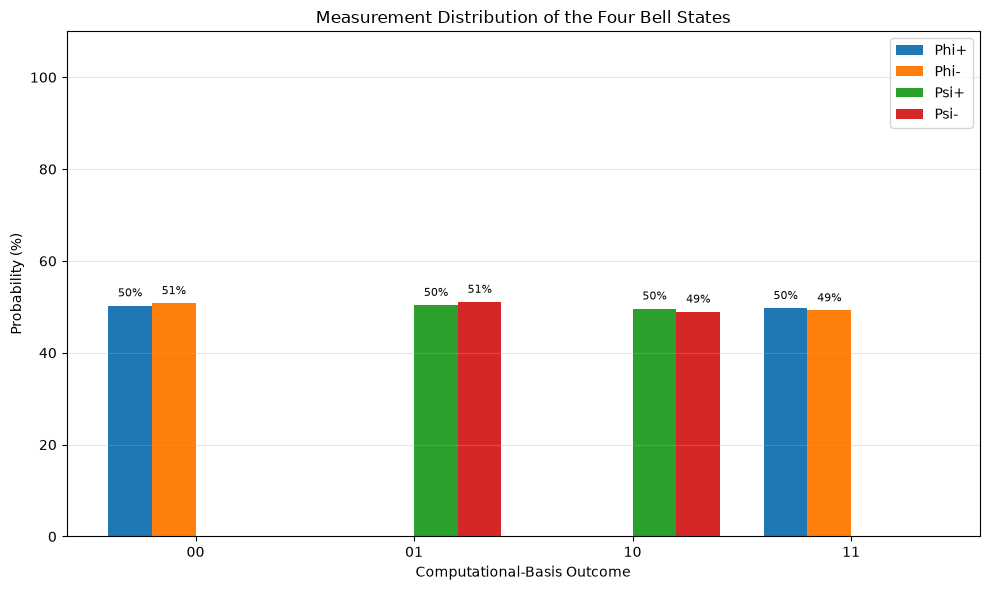

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

bell_states = {
    "Phi+": "00",
    "Phi-": "00",
    "Psi+": "01",
    "Psi-": "01"
}

def create_bell_state(name):
    qc = QuantumCircuit(2)

    if name == "Phi+":
        qc.h(0)
        qc.cx(0, 1)

    elif name == "Phi-":
        qc.h(0)
        qc.cx(0, 1)
        qc.z(0)

    elif name == "Psi+":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)

    elif name == "Psi-":
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.z(0)

    return qc

outcomes = ["00", "01", "10", "11"]

rng = np.random.default_rng(SEED)

all_counts = {}

print("\nFOUR BELL STATES")
print("=" * 70)

for name in bell_states:

    qc = create_bell_state(name)

    state = Statevector.from_instruction(qc)
    probabilities = state.probabilities_dict()

    probs = np.array([
        probabilities.get(outcome, 0)
        for outcome in outcomes
    ])

    samples = rng.choice(
        outcomes,
        size=SHOTS,
        p=probs
    )

    counts = {
        outcome: int(np.sum(samples == outcome))
        for outcome in outcomes
    }

    all_counts[name] = counts

    print(f"\n{name} STATE")
    print("-" * 50)

    print(qc.draw())

    for outcome in outcomes:
        print(
            f"{outcome} : "
            f"{counts[outcome]} "
            f"({counts[outcome] / SHOTS:.4f})"
        )

print("\nCOMPARISON TABLE")
print("=" * 70)

print(
    f"{'Bell State':<12}"
    f"{'00':<12}"
    f"{'01':<12}"
    f"{'10':<12}"
    f"{'11':<12}"
)

print("-" * 60)

for name, counts in all_counts.items():

    print(
        f"{name:<12}"
        f"{counts['00']:<12}"
        f"{counts['01']:<12}"
        f"{counts['10']:<12}"
        f"{counts['11']:<12}"
    )

# Visualization
x = np.arange(len(outcomes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for index, (name, counts) in enumerate(all_counts.items()):

    values = [
        counts[outcome] / SHOTS * 100
        for outcome in outcomes
    ]

    positions = x + (index - 1.5) * width

    bars = ax.bar(
        positions,
        values,
        width,
        label=name
    )

    for bar, value in zip(bars, values):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 2,
                f"{value:.0f}%",
                ha="center",
                fontsize=8
            )

ax.set_title("Measurement Distribution of the Four Bell States")
ax.set_xlabel("Computational-Basis Outcome")
ax.set_ylabel("Probability (%)")
ax.set_xticks(x)
ax.set_xticklabels(outcomes)
ax.set_ylim(0, 110)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Results and Observation

### Recorded Execution Output
The cell executes across all four Bell states, displaying circuit diagrams, measurement frequencies, and a structured comparison table:

```
FOUR BELL STATES
======================================================================

Phi+ STATE
--------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
00 : 515 (0.5029)
01 : 0 (0.0000)
10 : 0 (0.0000)
11 : 509 (0.4971)

Phi- STATE
--------------------------------------------------
     ┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ Z ├
     └───┘┌─┴─┐└───┘
q_1: ─────┤ X ├─────
          └───┘     
00 : 520 (0.5078)
01 : 0 (0.0000)
10 : 0 (0.0000)
11 : 504 (0.4922)

Psi+ STATE
--------------------------------------------------
     ┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐┌───┐
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘
00 : 0 (0.0000)
01 : 516 (0.5039)
10 : 508 (0.4961)
11 : 0 (0.0000)

Psi- STATE
--------------------------------------------------
     ┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ Z ├
     └───┘┌─┴─┐├───┤
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘
00 : 0 (0.0000)
01 : 523 (0.5107)
10 : 501 (0.4893)
11 : 0 (0.0000)

COMPARISON TABLE
======================================================================
Bell State  00          01          10          11          
------------------------------------------------------------
Phi+        515         0           0           509         
Phi-        520         0           0           504         
Psi+        0           516         508         0           
Psi-        0           523         501         0           
```

### Comprehensive Comparison Summary Table

| Bell State | Mathematical Expression | Circuit Gates | Counts: `00` | Counts: `01` | Counts: `10` | Counts: `11` | Subspace Type |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **$|\Phi^+\rangle$** | $\frac{\|00\rangle + \|11\rangle}{\sqrt{2}}$ | $H_0 \to \text{CX}_{01}$ | **515 (50.29%)** | **0 (0.0%)** | **0 (0.0%)** | **509 (49.71%)** | Correlated ($\Phi$) |
| **$|\Phi^-\rangle$** | $\frac{\|00\rangle - \|11\rangle}{\sqrt{2}}$ | $H_0 \to \text{CX}_{01} \to Z_0$ | **520 (50.78%)** | **0 (0.0%)** | **0 (0.0%)** | **504 (49.22%)** | Correlated ($\Phi$) |
| **$|\Psi^+\rangle$** | $\frac{\|01\rangle + \|10\rangle}{\sqrt{2}}$ | $H_0 \to \text{CX}_{01} \to X_1$ | **0 (0.0%)** | **516 (50.39%)** | **508 (49.61%)** | **0 (0.0%)** | Anti-correlated ($\Psi$) |
| **$|\Psi^-\rangle$** | $\frac{\|01\rangle - \|10\rangle}{\sqrt{2}}$ | $H_0 \to \text{CX}_{01} \to X_1 \to Z_0$ | **0 (0.0%)** | **523 (51.07%)** | **501 (48.93%)** | **0 (0.0%)** | Anti-correlated ($\Psi$) |

---

## 6. Visualization Analysis
The grouped bar chart illustrates the measurement probability distribution across all four computational basis outcomes (`00`, `01`, `10`, `11`):
- **X-Axis**: Categorical computational-basis measurement outcomes.
- **Y-Axis**: Probability percentage from $0\%$ to $110\%$.
- **Grouped Bars**:
  - `Phi+` and `Phi-` bars cluster exclusively at outcomes `00` ($\approx 50\%$) and `11` ($\approx 50\%$).
  - `Psi+` and `Psi-` bars cluster exclusively at outcomes `01` ($\approx 50\%$) and `10` ($\approx 50\%$).
- **Physical Meaning**: Confirms the clear geometric separation between the correlated $\Phi$ and anti-correlated $\Psi$ Bell subspaces in the computational basis.

---

## 7. Conclusion
This comparative experiment demonstrates the fundamental properties of the **Four Bell States**:
1. **Maximal Entanglement**: Validates that all four states exhibit complete pair-wise correlation (or anti-correlation) with $0\%$ probability on forbidden cross-terms.
2. **Subspace Segregation**: Demonstrates that computational-basis measurement partitions the Bell basis into the correlated $\Phi$ subspace ($\{00, 11\}$) and the anti-correlated $\Psi$ subspace ($\{01, 10\}$).
3. **Phase Invariance in Computational Measurement**: Proves that relative phase factors ($|\Phi^+\rangle$ vs. $|\Phi^-\rangle$, and $|\Psi^+\rangle$ vs. $|\Psi^-\rangle$) yield indistinguishable computational-basis distributions, illustrating the necessity of basis-rotation transformations for complete quantum state tomography.